In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("breast-cancer-wisconsin.data")

In [3]:
df.head()

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
df.columns

Index(['id', ' clump_thickness', ' unif_cell_size', ' unif_cell_shape',
       ' marg_adhesion', ' single_epith_cell_size', ' bare_nulei',
       ' bland_chrom', ' norm_nucleoli', ' mitoses', ' class'],
      dtype='object')

In [5]:
df.columns = df.columns.str.replace(' ', '')
df.columns

Index(['id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
       'marg_adhesion', 'single_epith_cell_size', 'bare_nulei', 'bland_chrom',
       'norm_nucleoli', 'mitoses', 'class'],
      dtype='object')

In [7]:
df = df[df['bare_nulei'] !='?']

In [8]:
df.drop(['id'] , axis = 1 , inplace=True)

In [9]:
df.head()

,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses,class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [10]:
x = df.iloc[: , :9]

In [11]:
y = df.iloc[: , 9]

In [12]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2 , random_state = 0)

In [13]:
import math
k = math.sqrt(len(y_test))

In [14]:
k

11.704699910719626

In [15]:
if k % 2 ==0: k + 1
k = int(k)
k

11

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
model = KNeighborsClassifier(n_neighbors = k)

In [18]:
model.fit(x_train , y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
model.score(x_test, y_test)

0.9562043795620438

In [22]:
k_range = range(1, 16)
scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    accuracy = model.score(x_test, y_test)
    scores.append(accuracy)
    print('k = %d, accuracy = %.2f%%' % (k, accuracy * 100))

k = 1, accuracy = 97.08%
k = 2, accuracy = 94.89%
k = 3, accuracy = 97.08%
k = 4, accuracy = 97.08%
k = 5, accuracy = 97.08%
k = 6, accuracy = 95.62%
k = 7, accuracy = 97.08%
k = 8, accuracy = 96.35%
k = 9, accuracy = 96.35%
k = 10, accuracy = 94.89%
k = 11, accuracy = 95.62%
k = 12, accuracy = 94.89%
k = 13, accuracy = 94.89%
k = 14, accuracy = 94.16%
k = 15, accuracy = 95.62%


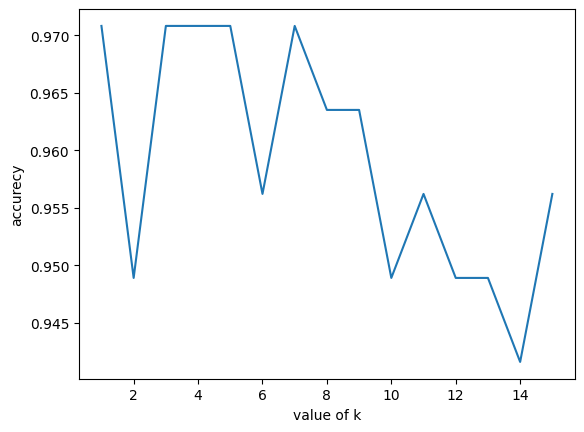

In [23]:
plt.plot(k_range, scores)
plt.xlabel("value of k")
plt.ylabel("accurecy")
plt.show()

In [24]:
model = KNeighborsClassifier(n_neighbors=3)

In [25]:
model.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
model.score(x_test ,y_test)

0.9708029197080292

In [27]:
model.predict([[4,2,1,1,1,2,3,2,1]])

array([2], dtype=int64)

In [31]:
model.predict([[4,2,1,1,1,2,3,2,1] ,[8,10,10,8,7,10,9,7,1]])

array([2, 4], dtype=int64)